<a href="https://colab.research.google.com/github/ajaypayer/Air-Dust-Size-Measurment/blob/main/Air_Dust_size_measurment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Importing the neccesary Libraries

In [2]:
import pandas as pd # for data manupulation
import numpy as np # for numerial commutation
import matplotlib.pyplot as plt # ploting the graphs



Data Collection

In [4]:
Autumn = pd.read_csv("/content/Autumn_Oct&Nov_B12491_AV.csv") # "Autumn" seasonal dataset of reference insrtument
LCS = pd.read_csv("/content/NE_50_E-BAM_AV_2023.csv") # Low-cost sensor dataset for the year 2023


In [ ]:
Autumn.head()

,Time,ConcRT(ug/m3),ConcHR(ug/m3),ConcS(ug/m3),Flow(lpm),WS(m/s),WD(Deg),AT(C),RH(%),BP(mmHg),FT(C),FRH(%),Status
0,16-10-2023 13:00,100.8,80.1,83.1,16.67,0,0,28.0,55,741.3,35.3,28,768
1,16-10-2023 13:15,49.9,80.1,83.1,16.47,0,0,27.4,58,741.4,34.4,30,256
2,16-10-2023 13:30,45.8,80.1,83.1,16.67,0,0,27.4,59,741.5,33.9,32,256
3,16-10-2023 13:45,41.1,80.1,83.1,16.67,0,0,27.6,60,741.5,34.2,32,256
4,16-10-2023 14:00,60.8,51.1,52.8,16.67,0,0,26.9,61,741.6,34.2,32,0


In [5]:
LCS.head()

,TIMESTAMP,PM₁,PM₂.₅,PM₂.₅ _Cal,PM₁₀,PM 1 CF-1-A,PM 1 CF-1-B,PM 1 ATM-A,PM 1 ATM-B,PM 2.5 CF-1-A,...,Humidity,Pressure,Biomass burning(%),Dust(%),Gasoline Vehicle(%),Diesel Vehicle(%),Coal Combustion(%),Waste Burning(%),Industries(%),Secondary Aerosol(%)
0,8-2-2023 13:13:30,31.80,48.02,NaN,59.14,44.29,46.75,31.18,32.42,64.71,...,26,991.61,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,8-2-2023 13:15:34,31.48,47.17,NaN,57.83,43.64,44.81,31.11,31.85,63.24,...,26,991.62,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,8-2-2023 13:17:31,32.89,49.30,NaN,60.90,47.52,48.53,32.74,33.04,68.89,...,26,991.60,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,8-2-2023 13:19:31,34.80,52.47,NaN,64.14,51.33,53.48,34.33,35.27,76.21,...,26,991.60,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,8-2-2023 13:21:31,35.01,53.77,NaN,66.22,53.38,53.06,35.20,34.81,80.53,...,26,991.50,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Data Cleaning and preprocessing

In [6]:
# Cleaning uncommon values from the reference dataset
# Remove rows with None values in specific columns
Autumn = Autumn.dropna(subset=['ConcRT(ug/m3)', 'ConcHR(ug/m3)', 'AT(C)', 'RH(%)'])


In [7]:
# Remove rows with 'ConcRT(ug/m3)' and 'ConcHR(ug/m3)' values less than 0 or greater than 1000
Autumn = Autumn[(Autumn['ConcRT(ug/m3)'].between(0, 1000)) & (Autumn['ConcHR(ug/m3)'].between(0, 1000))]


In [8]:
Autumn.columns # for checking the colums

Index(['Time', 'ConcRT(ug/m3)', 'ConcHR(ug/m3)', 'ConcS(ug/m3)', 'Flow(lpm)',
       'WS(m/s)', 'WD(Deg)', 'AT(C)', 'RH(%)', 'BP(mmHg)', 'FT(C)', 'FRH(%)',
       'Status'],
      dtype='object')

In [9]:
Autumn['Time'] = pd.to_datetime(Autumn['Time'], format='%d-%m-%Y %H:%M')


In [11]:
# Function to calculate hourly averages
def hourly_average(df):
    # Group by hour and calculate mean for each group
    hourly_df = df.groupby(df['Time'].dt.floor('H')).mean()
    # Copy 'Time' column to the new DataFrame
    hourly_df['Time'] = hourly_df.index
    # Reset index
    hourly_df.reset_index(drop=True, inplace=True)
    # Reorder columns
    hourly_df = hourly_df[['Time'] + [col for col in hourly_df.columns if col != 'Time']]
    # Format the 'Time' column
    hourly_df['Time'] = hourly_df['Time'].dt.strftime('%d-%m-%Y %H:%M')
    return hourly_df


In [12]:
# Apply hourly averaging to each data frame
Autumn_hr = hourly_average(Autumn)

# Format 'Time' column
Autumn['Time'] = Autumn['Time'].dt.strftime('%d-%m-%Y %H:%M')

/tmp/ipykernel_1266/2986249389.py:4: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  hourly_df = df.groupby(df['Time'].dt.floor('H')).mean()


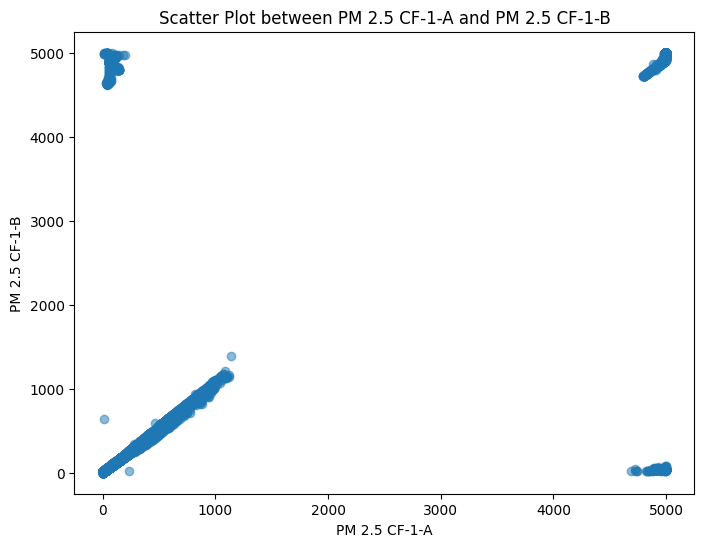

In [13]:
#  check the performance quality of LCS two sensor channels
plt.figure(figsize=(8, 6))
plt.scatter(LCS['PM 2.5 CF-1-A'], LCS['PM 2.5 CF-1-B'], alpha=0.5)
plt.title('Scatter Plot between PM 2.5 CF-1-A and PM 2.5 CF-1-B')
plt.xlabel('PM 2.5 CF-1-A')
plt.ylabel('PM 2.5 CF-1-B')
plt.grid(False)
plt.show()

In [14]:
# Filtering the DataFrame in-place
LCS = LCS[(LCS['PM 2.5 CF-1-A'] <= 2000) & (LCS['PM 2.5 CF-1-B'] <= 2000)]

# Averaging the PM2.5 values for two sensor channel outputs of LCS
LCS['PM₂.₅-AVG'] = LCS[['PM 2.5 CF-1-A', 'PM 2.5 CF-1-B']].mean(axis=1)


In [15]:
# Conversion to hourly average data frame of LCS
LCS['TIMESTAMP'] = pd.to_datetime(LCS['TIMESTAMP'], format='%d-%m-%Y %H:%M:%S')

# Set 'TIMESTAMP' as the DataFrame index
LCS.set_index('TIMESTAMP', inplace=True)

# Resample to hourly averages
LCS_hr = LCS.resample('H').mean()

# Format the index as 'dd-mm-yyyy hh:mm'
LCS_hr.index = LCS_hr.index.strftime('%d-%m-%Y %H:%M')

# Drop rows where all columns have NaN values
LCS_hr.dropna(how='all', inplace=True)

# Reset the index if you want to keep 'TIMESTAMP' as a regular column
LCS_hr.reset_index(inplace=True)


/tmp/ipykernel_1266/793779448.py:8: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  LCS_hr = LCS.resample('H').mean()


In [16]:
# Add suffixes to all columns of LCS_hr DataFrame
LCS_hr.columns = [col + '_LCS' for col in LCS_hr.columns]

# Add suffixes to all columns of Autumn_hr DataFrame
Autumn_hr.columns = [col + '_Atmn' for col in Autumn_hr.columns]


In [17]:
# Merge the DataFrames based on the 'Time' column common in two datasets
Autumn_df = pd.merge(LCS_hr, Autumn_hr, left_on='TIMESTAMP_LCS', right_on='Time_Atmn', how='inner')


In [18]:
Autumn_df.head()

,TIMESTAMP_LCS,PM₁_LCS,PM₂.₅_LCS,PM₂.₅ _Cal_LCS,PM₁₀_LCS,PM 1 CF-1-A_LCS,PM 1 CF-1-B_LCS,PM 1 ATM-A_LCS,PM 1 ATM-B_LCS,PM 2.5 CF-1-A_LCS,...,ConcS(ug/m3)_Atmn,Flow(lpm)_Atmn,WS(m/s)_Atmn,WD(Deg)_Atmn,AT(C)_Atmn,RH(%)_Atmn,BP(mmHg)_Atmn,FT(C)_Atmn,FRH(%)_Atmn,Status_Atmn
0,17-10-2023 15:00,25.969000,37.981333,105.948000,44.730000,32.478000,33.834667,26.287333,25.647333,45.159333,...,58.0,16.6200,0.0,0.0,25.600,62.75,743.975,31.450,35.00,0.0
1,17-10-2023 16:00,35.302000,51.806400,140.439600,59.564800,51.382800,51.997600,35.327600,35.276800,73.897600,...,59.0,16.6225,0.0,0.0,25.325,63.00,743.950,30.475,36.25,0.0
2,17-10-2023 17:00,29.325000,42.678750,127.718333,51.342500,39.832917,41.015000,29.568750,29.080417,54.812500,...,62.8,16.6200,0.0,0.0,24.925,65.25,743.825,29.700,38.25,0.0
3,17-10-2023 18:00,24.790000,35.311333,110.330000,41.096000,29.129000,30.233333,24.942667,24.638000,39.287000,...,82.1,16.6200,0.0,0.0,23.475,69.25,743.850,28.150,41.50,0.0
4,17-10-2023 19:00,24.985667,35.449000,110.136000,41.372333,29.589000,30.599333,25.166000,24.804333,39.589000,...,93.5,16.6200,0.0,0.0,22.000,73.25,744.075,26.375,45.25,0.0


In [19]:
# Reset the index after merging if needed
Autumn_df.reset_index(drop=True, inplace=True)

In [20]:
Autumn_df

,TIMESTAMP_LCS,PM₁_LCS,PM₂.₅_LCS,PM₂.₅ _Cal_LCS,PM₁₀_LCS,PM 1 CF-1-A_LCS,PM 1 CF-1-B_LCS,PM 1 ATM-A_LCS,PM 1 ATM-B_LCS,PM 2.5 CF-1-A_LCS,...,ConcS(ug/m3)_Atmn,Flow(lpm)_Atmn,WS(m/s)_Atmn,WD(Deg)_Atmn,AT(C)_Atmn,RH(%)_Atmn,BP(mmHg)_Atmn,FT(C)_Atmn,FRH(%)_Atmn,Status_Atmn
0,17-10-2023 15:00,25.969000,37.981333,105.948000,44.730000,32.478000,33.834667,26.287333,25.647333,45.159333,...,58.0,16.6200,0.0,0.0,25.600,62.75,743.975,31.450,35.00,0.0
1,17-10-2023 16:00,35.302000,51.806400,140.439600,59.564800,51.382800,51.997600,35.327600,35.276800,73.897600,...,59.0,16.6225,0.0,0.0,25.325,63.00,743.950,30.475,36.25,0.0
2,17-10-2023 17:00,29.325000,42.678750,127.718333,51.342500,39.832917,41.015000,29.568750,29.080417,54.812500,...,62.8,16.6200,0.0,0.0,24.925,65.25,743.825,29.700,38.25,0.0
3,17-10-2023 18:00,24.790000,35.311333,110.330000,41.096000,29.129000,30.233333,24.942667,24.638000,39.287000,...,82.1,16.6200,0.0,0.0,23.475,69.25,743.850,28.150,41.50,0.0
4,17-10-2023 19:00,24.985667,35.449000,110.136000,41.372333,29.589000,30.599333,25.166000,24.804333,39.589000,...,93.5,16.6200,0.0,0.0,22.000,73.25,744.075,26.375,45.25,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
697,27-11-2023 11:00,143.404667,249.172000,129.509000,262.781000,210.173667,221.653667,139.536333,147.274000,372.163000,...,238.0,16.6175,0.0,0.0,20.475,66.75,746.075,23.425,42.50,0.0
698,27-11-2023 12:00,149.902000,263.387000,165.222333,277.714667,218.630000,232.692333,145.209667,154.593000,391.987333,...,231.6,16.6175,0.0,0.0,22.250,63.00,745.175,25.775,38.00,0.0
699,27-11-2023 13:00,126.925333,224.305000,165.941333,236.826667,186.326333,196.063000,123.664667,130.186000,335.984333,...,311.9,16.6200,0.0,0.0,22.325,59.50,744.550,26.900,33.50,0.0
700,27-11-2023 14:00,122.256000,214.234000,165.890000,225.919000,179.749000,188.655000,119.286667,125.225333,321.717000,...,206.5,16.6175,0.0,0.0,22.600,57.50,743.825,26.525,34.25,0.0


In [21]:
# Time Series Plot with Outliers to visualize outliers in the current hourly dataset
# Define x_ticks_interval
x_ticks_interval = 30
x = Autumn_df['Time_Atmn']


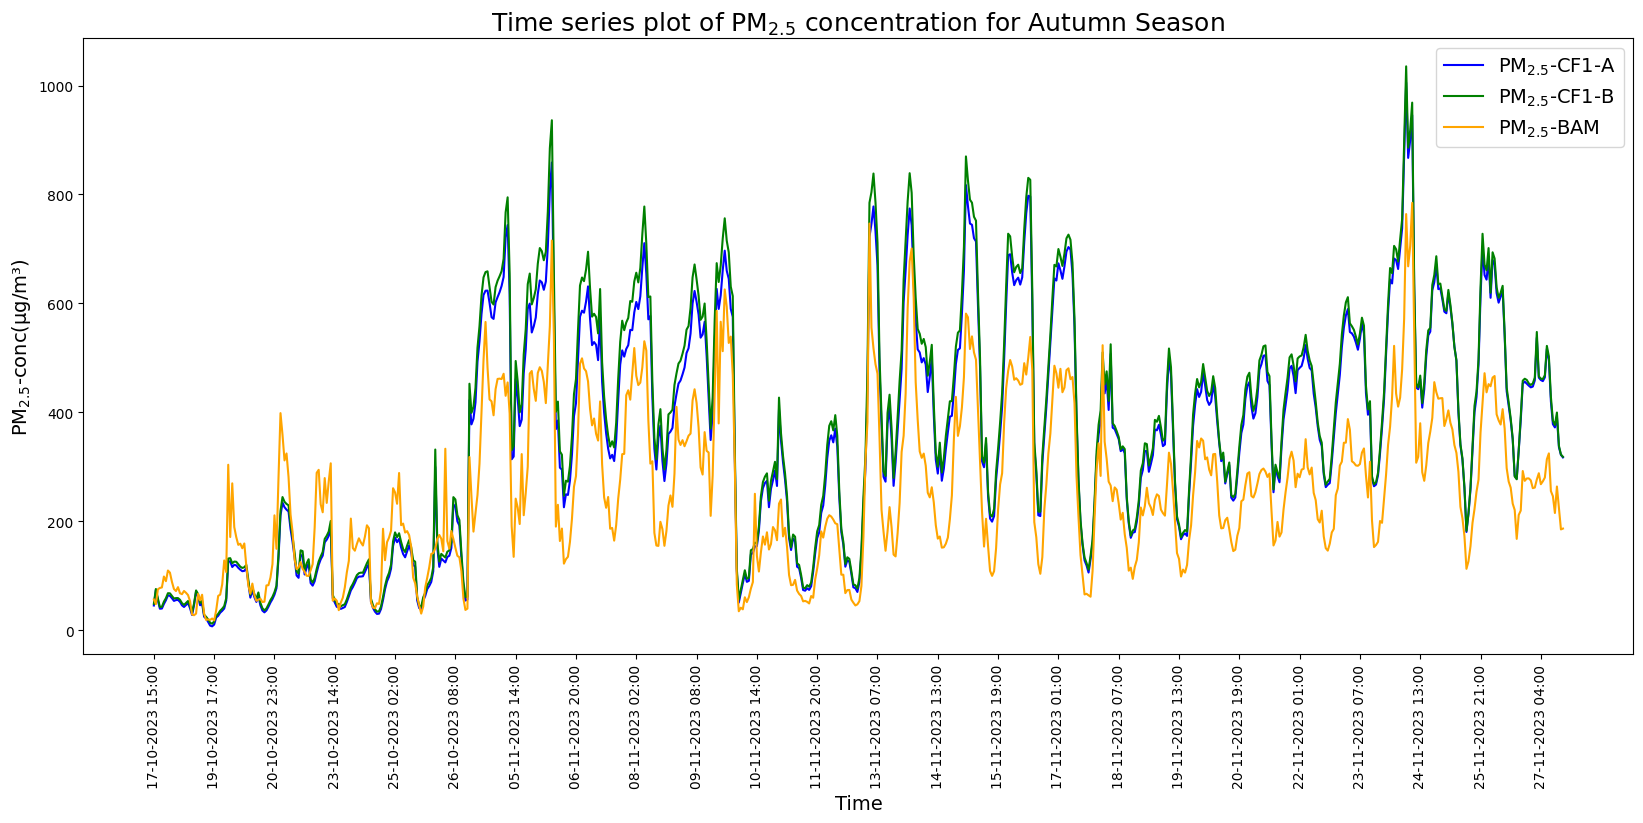

In [22]:
# Plot line graph for 'PM₂.₅-AVG_LCS' and 'ConcRT(ug/m3)' for Autumn_min_df
plt.figure(figsize=(20, 8))
plt.plot(x, Autumn_df['PM 2.5 CF-1-A_LCS'], label="PM$_{2.5}$-CF1-A", color="blue")
plt.plot(x, Autumn_df['PM 2.5 CF-1-B_LCS'], label="PM$_{2.5}$-CF1-B", color="green")
plt.plot(x, Autumn_df['ConcRT(ug/m3)_Atmn'], label="PM$_{2.5}$-BAM", color="orange")

plt.ylabel("PM$_{2.5}$-conc(µg/m³)", fontsize=14)  # Use "µ" for micro symbol
plt.xlabel("Time", fontsize=14)
plt.title("Time series plot of PM$_{2.5}$ concentration for Autumn Season", fontsize=18)
plt.legend(fontsize=14)
plt.xticks(x[::x_ticks_interval], rotation=90)
plt.show()

In [23]:
# Descriptive statistical summary of the Autumn dataframe with outliers
Autumn_df[['PM₂.₅-AVG_LCS', 'ConcRT(ug/m3)_Atmn', 'Temperature_LCS', 'AT(C)_Atmn', 'Humidity_LCS', 'RH(%)_Atmn']].describe()


,PM₂.₅-AVG_LCS,ConcRT(ug/m3)_Atmn,Temperature_LCS,AT(C)_Atmn,Humidity_LCS,RH(%)_Atmn
count,702.000000,702.000000,702.000000,702.000000,702.000000,702.000000
mean,364.607182,254.742901,27.331889,22.048801,61.979671,68.178894
std,217.019589,146.367454,3.967114,3.824549,16.837080,13.537076
min,9.323333,17.800000,20.205333,15.300000,34.000000,40.000000
25%,163.570167,150.125000,23.890000,19.006250,45.557407,56.750000
50%,365.470583,232.800000,27.129667,21.512500,61.750000,69.125000
75%,532.317625,347.268750,30.864651,24.925000,78.525000,79.437500
max,1020.358500,784.575000,35.687333,31.533333,93.700000,93.000000


In [24]:
# Define columns to check for outliers
columns_to_check = ['PM₂.₅-AVG_LCS', 'ConcRT(ug/m3)_Atmn']


In [25]:
columns_to_check

['PM₂.₅-AVG_LCS', 'ConcRT(ug/m3)_Atmn']

In [26]:

# Function to remove outlier rows from a DataFrame using box-whisker plot method
def remove_outliers(df):
    # Calculate the first and third quartiles
    Q1 = df[columns_to_check].quantile(0.25)
    Q3 = df[columns_to_check].quantile(0.75)

    # Calculate the interquartile range (IQR)
    IQR = Q3 - Q1

    #  thresholds for outlier detection
    lower_threshold = Q1 - 1.5 * IQR
    upper_threshold = Q3 + 1.5 * IQR

    # Create masks to identify outlier rows
    lower_outlier_mask = (df[columns_to_check] < lower_threshold).any(axis=1)
    upper_outlier_mask = (df[columns_to_check] > upper_threshold).any(axis=1)

    # Combine masks to identify rows with outliers
    outlier_mask = lower_outlier_mask | upper_outlier_mask

    # Create a new DataFrame without the outlier rows
    return df[~outlier_mask].copy()


In [27]:
# Remove outlier rows for all data frames
Autumn_df = remove_outliers(Autumn_df)

In [28]:
#Descriptive statistical summary of the Autumn dataframe without outliers
Autumn_df[['PM₂.₅-AVG_LCS', 'ConcRT(ug/m3)_Atmn', 'Temperature_LCS', 'AT(C)_Atmn', 'Humidity_LCS', 'RH(%)_Atmn']].describe()


,PM₂.₅-AVG_LCS,ConcRT(ug/m3)_Atmn,Temperature_LCS,AT(C)_Atmn,Humidity_LCS,RH(%)_Atmn
count,694.000000,694.000000,694.000000,694.000000,694.000000,694.000000
mean,358.733812,249.377113,27.380944,22.093636,61.759600,68.027137
std,211.007456,138.287406,3.957236,3.822052,16.802112,13.527441
min,9.323333,17.800000,20.205333,15.300000,34.000000,40.000000
25%,159.840458,149.356250,23.890000,19.106250,45.508333,56.750000
50%,362.188380,231.487500,27.220000,21.537500,61.333333,68.875000
75%,523.259542,342.312500,30.899667,24.950000,78.225000,79.250000
max,885.392000,625.550000,35.687333,31.533333,93.700000,93.000000


Preliminary Data Analysis

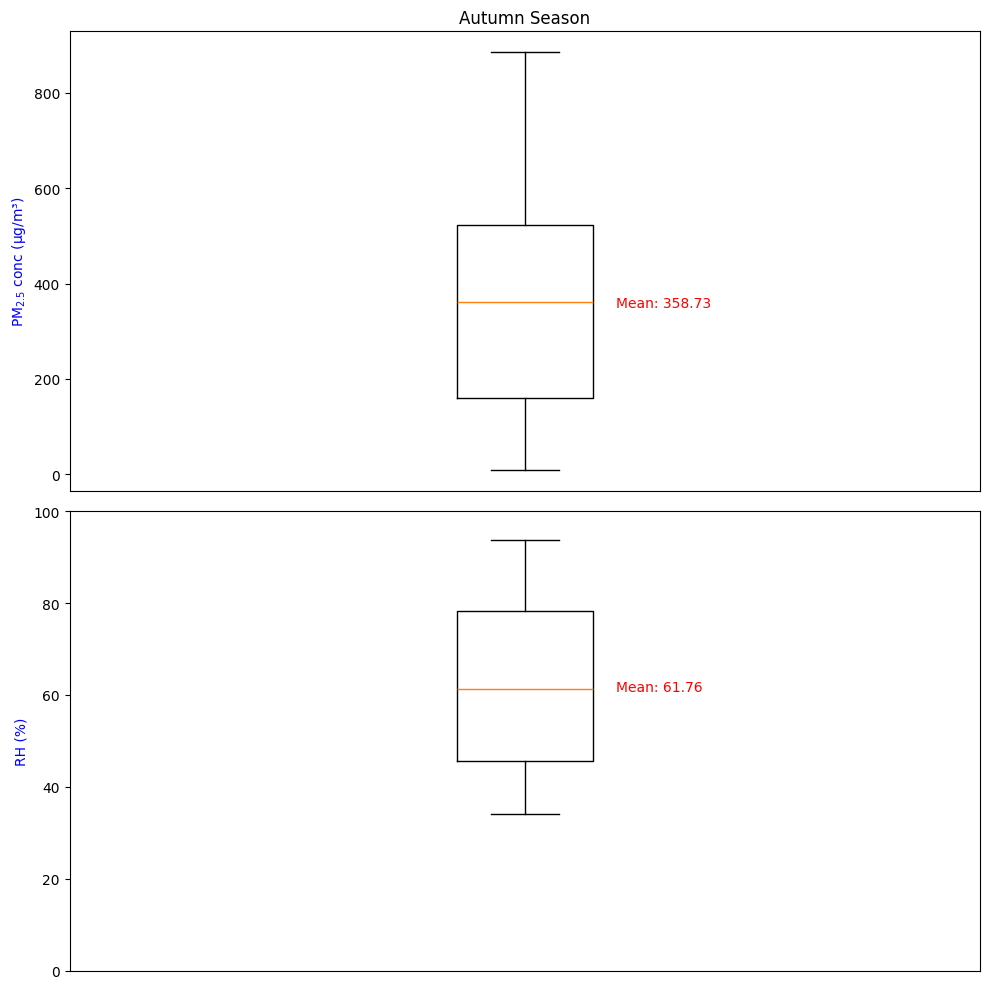

In [29]:
# Plotting a Box-Whisker plot
# Create a grid of subplots with two rows and one column (since we are only plotting Autumn data)
fig, axs = plt.subplots(2, 1, figsize=(10, 10))

# Plot box-whisker plot for 'PM₂.₅-AVG_LCS' values in Autumn_df
axs[0].boxplot(Autumn_df['PM₂.₅-AVG_LCS'])
axs[0].set_ylabel('PM$_{2.5}$ conc (µg/m³)', color='blue')
axs[0].set_title('Autumn Season')
axs[0].tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)

# Plot box-whisker plot for 'Humidity_LCS' values in Autumn_df
axs[1].boxplot(Autumn_df['Humidity_LCS'])
axs[1].set_ylabel('RH (%)', color='blue')
axs[1].set_ylim(0, 100)
axs[1].tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)

# Calculate mean values for 'PM₂.₅-AVG_LCS' and 'Humidity_LCS'
pm_mean = Autumn_df['PM₂.₅-AVG_LCS'].mean()
rh_mean = Autumn_df['Humidity_LCS'].mean()

# Add mean values to the boxplots
axs[0].text(1.1, pm_mean, f'Mean: {pm_mean:.2f}', color='red', fontsize=10, va='center')
axs[1].text(1.1, rh_mean, f'Mean: {rh_mean:.2f}', color='red', fontsize=10, va='center')

# Adjust layout to prevent overlap
plt.tight_layout()

plt.show()

In [30]:


from matplotlib.font_manager import FontProperties

x_ticks_interval = 10

# Define x
x = Autumn_df['TIMESTAMP_LCS']

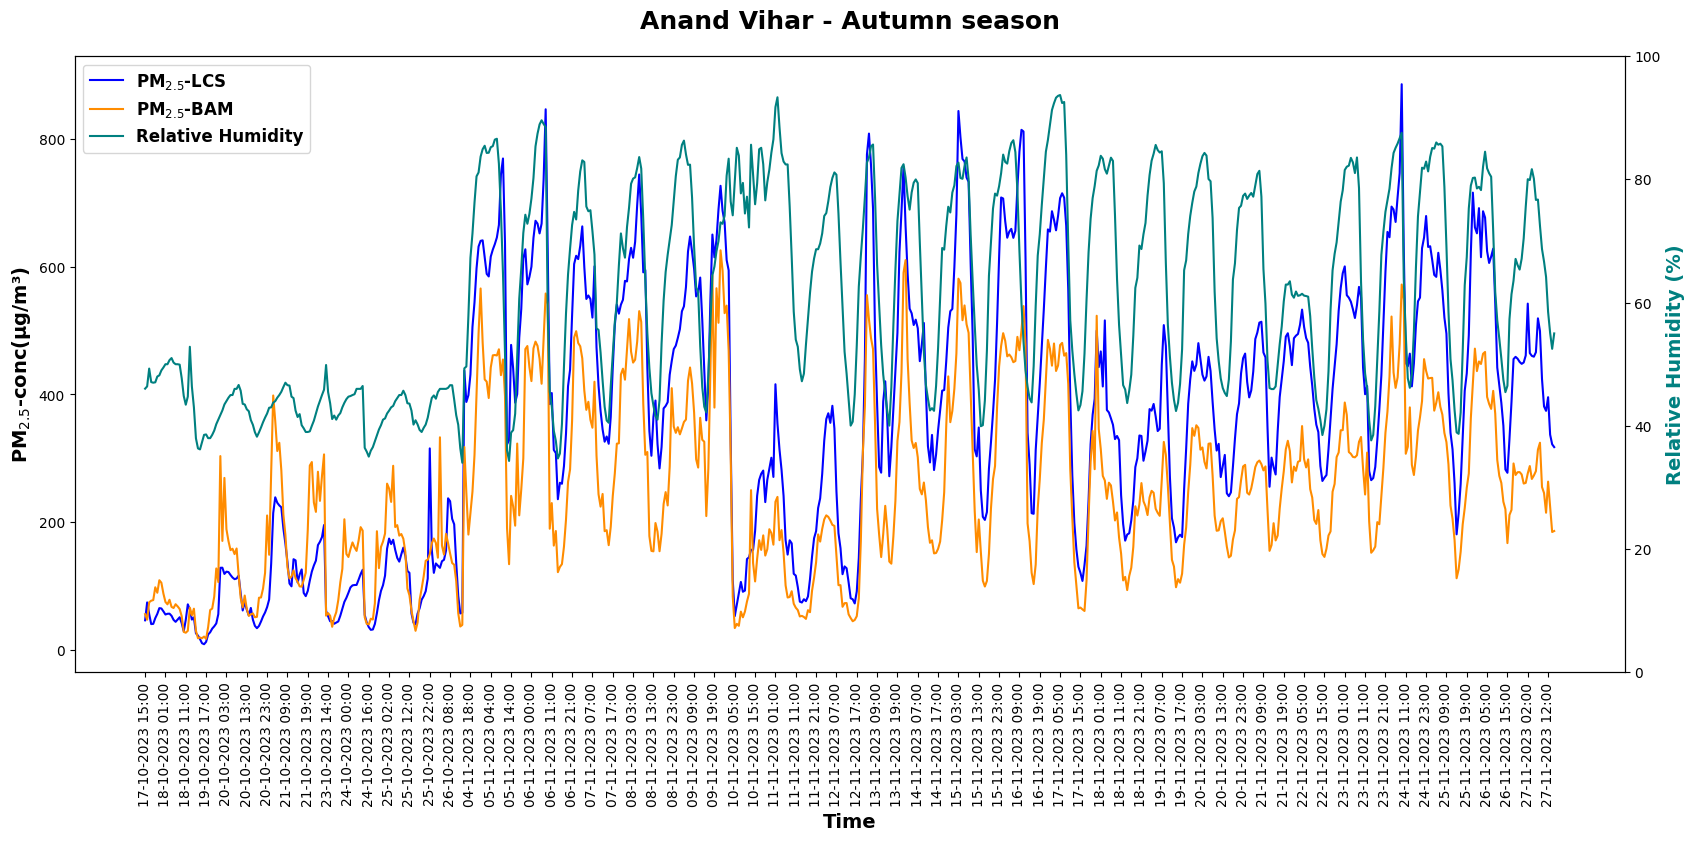

In [31]:
# Create figure and axis objects
fig, ax1 = plt.subplots(figsize=(20, 8))

# Plot PM 2.5 Average on primary y-axis
line1, = ax1.plot(x, Autumn_df['PM₂.₅-AVG_LCS'], label="PM$_{2.5}$-LCS", color="blue")
line2,= ax1.plot(x, Autumn_df['ConcRT(ug/m3)_Atmn'], label="PM$_{2.5}$-BAM", color="darkorange")
ax1.set_ylabel("PM$_{2.5}$-conc(µg/m³)", fontsize=14, fontweight='bold')
ax1.set_xlabel("Time", fontsize=14, fontweight='bold')


# Create a secondary y-axis for Relative Humidity (%)
ax2 = ax1.twinx()
line3, = ax2.plot(x, Autumn_df['Humidity_LCS'], label='Relative Humidity', color='teal')
ax2.set_ylabel('Relative Humidity (%)', fontsize=14, color='teal', fontweight='bold')
ax2.set_ylim(0, 100)

# give the title
plt.title("Anand Vihar - Autumn season", fontsize=18, fontweight='bold', loc='center', pad=20)

# Bold the legend and place it inside the plot
fontP = FontProperties()
fontP.set_size('large')
fontP.set_weight('bold')

# Combine legends from both axes
lines = [line1, line2, line3]
labels = [line.get_label() for line in lines]
ax1.legend(lines, labels, prop=fontP, loc='upper left')

# Set x-ticks and rotate them
ax1.set_xticks(x[::x_ticks_interval])
ax1.set_xticklabels(x[::x_ticks_interval], rotation=90)

# Save the figure with high DPI and tight bounding box
fig.savefig("Anand_Vihar_Autumn_season.png", dpi=2000, bbox_inches='tight')

# Show the plot
plt.show()

Machine learning models


Multi-linear Regression

In [32]:

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import matplotlib.pyplot as plt


# Define the dependent variable (target) and independent variables (features)
target_column = 'ConcRT(ug/m3)_Atmn'
independent_columns = ['PM₂.₅-AVG_LCS', 'Temperature_LCS', 'Humidity_LCS']

y = Autumn_df['ConcRT(ug/m3)_Atmn']
X = Autumn_df[['PM₂.₅-AVG_LCS', 'Temperature_LCS', 'Humidity_LCS']]

In [33]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


In [34]:
# Initialize the Linear Regression model
linear_regressor = LinearRegression()

# Fit the model to the training data
linear_regressor.fit(X_train, y_train)


LinearRegression()

In [35]:

# Predict on the training and test data
y_train_pred = linear_regressor.predict(X_train)
y_test_pred = linear_regressor.predict(X_test)

In [36]:
# Evaluate the model on the training and test data
mse_train = mean_squared_error(y_train, y_train_pred)
rmse_train = np.sqrt(mse_train)
mse_test = mean_squared_error(y_test, y_test_pred)
rmse_test = np.sqrt(mse_test)
r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_test_pred)
mae_test = mean_absolute_error(y_test, y_test_pred)

print("Train Mean Squared Error:", mse_train)
print("Train Root Mean Squared Error:", rmse_train)
print("Test Mean Squared Error:", mse_test)
print("Test Root  Mean Squared Error:", rmse_test)
print("Train R-squared:", r2_train)
print("Test R-squared:", r2_test)
print("Test Mean Absolute Error:", mae_test)

Train Mean Squared Error: 2580.4325159280734
Train Root Mean Squared Error: 50.79795779288842
Test Mean Squared Error: 2938.632385848334
Test Root  Mean Squared Error: 54.209154077963014
Train R-squared: 0.8672222874543937
Test R-squared: 0.835150147161354
Test Mean Absolute Error: 37.970344779797784


In [37]:
# Print the MLR equation
coefficients = linear_regressor.coef_
intercept = linear_regressor.intercept_
equation = f"ConcRT(ug/m3)_Atmn = {intercept:.2f} "
for i, coef in enumerate(coefficients):
    equation += f"+ ({coef:.2f} * {independent_columns[i]}) "
print("Multiple Linear Regression Equation (based on training data):")
print(equation.strip())

# Get the training score of the model
train_score = linear_regressor.score(X_train, y_train)

print("Training Score:", train_score)

Multiple Linear Regression Equation (based on training data):
ConcRT(ug/m3)_Atmn = -210.22 + (0.61 * PM₂.₅-AVG_LCS) + (5.87 * Temperature_LCS) + (1.32 * Humidity_LCS)
Training Score: 0.8672222874543937


In [38]:

# Calculate the residuals for the training data
residuals = y_train - y_train_pred

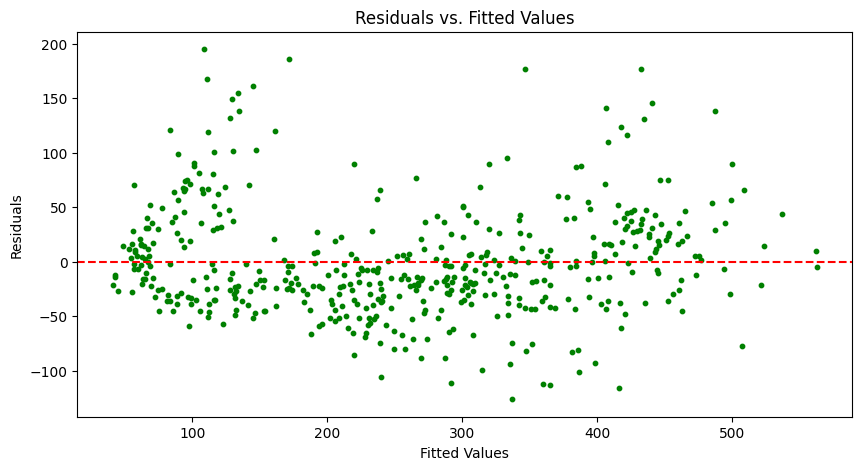

In [39]:
# Plot the residual plots
# Residual vs. Fitted (Predicted) plot
plt.figure(figsize=(10, 5))
plt.scatter(y_train_pred, residuals, s=10, c="green")
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.title('Residuals vs. Fitted Values')
plt.show()

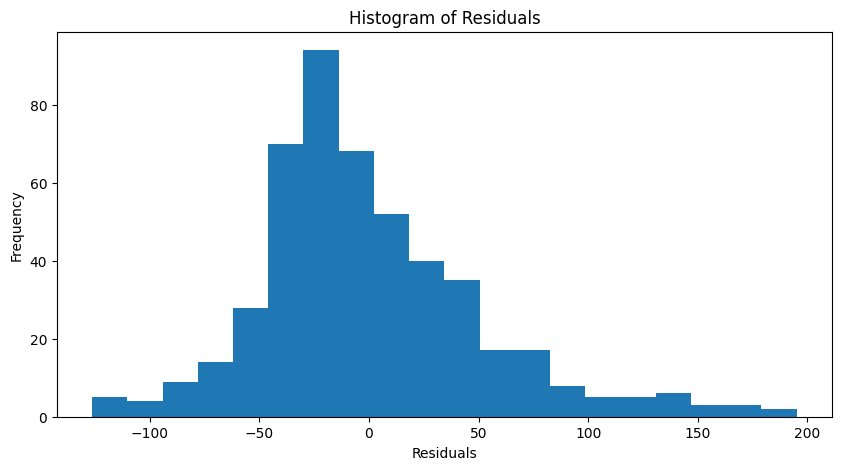

In [40]:
# Histogram of residuals
plt.figure(figsize=(10, 5))
plt.hist(residuals, bins=20)
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.title('Histogram of Residuals')
plt.show()

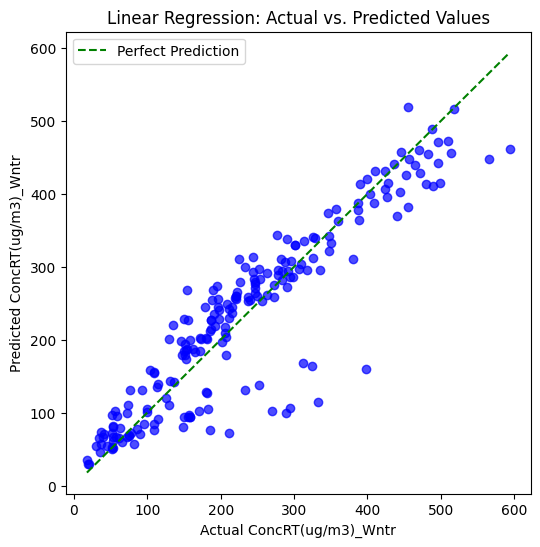

In [41]:
# Plot the predicted vs actual values of test data points
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_test_pred, color='blue', alpha=0.7)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], linestyle='--', color='green', label='Perfect Prediction')
plt.title("Linear Regression: Actual vs. Predicted Values")
plt.xlabel("Actual ConcRT(ug/m3)_Wntr")
plt.ylabel("Predicted ConcRT(ug/m3)_Wntr")
plt.legend()
plt.grid(False)
plt.show()


Random Forest Regressor

In [42]:

from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np

In [43]:
# Define your target variable and independent variables
target_column = 'ConcRT(ug/m3)_Atmn'
independent_columns = ['PM₂.₅-AVG_LCS', 'Temperature_LCS', 'Humidity_LCS']

In [44]:
# Split the data into training and testing sets
X = Autumn_df[independent_columns]
y = Autumn_df[target_column]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


In [45]:
# Initialize the Random Forest Regressor model
rf_regressor = RandomForestRegressor(random_state=42)

In [47]:
# Define the hyperparameter distributions for randomized search
param_distributions = {
    'n_estimators': list(range(100, 1100, 100)),  # Range from 100 to 1000 with step size of 100
    'max_depth': list(range(10, 110, 10)),        # Range from 10 to 100 with step size of 10
    'min_samples_split': list(range(2, 22, 2)),   # Range from 2 to 20 with step size of 2
    'min_samples_leaf': list(range(1, 11, 1))     # Range from 1 to 10 with default step size of 1
}

In [48]:
# Initialize RandomizedSearchCV
random_search = RandomizedSearchCV(estimator=rf_regressor, param_distributions=param_distributions,
                                   n_iter=100, scoring='neg_mean_squared_error', cv=5, random_state=42, n_jobs=-1)

# Fit RandomizedSearchCV to the training data
random_search.fit(X_train, y_train)


RandomizedSearchCV(cv=5, estimator=RandomForestRegressor(random_state=42),
                   n_iter=100, n_jobs=-1,
                   param_distributions={'max_depth': [10, 20, 30, 40, 50, 60,
                                                      70, 80, 90, 100],
                                        'min_samples_leaf': [1, 2, 3, 4, 5, 6,
                                                             7, 8, 9, 10],
                                        'min_samples_split': [2, 4, 6, 8, 10,
                                                              12, 14, 16, 18,
                                                              20],
                                        'n_estimators': [100, 200, 300, 400,
                                                         500, 600, 700, 800,
                                                         900, 1000]},
                   random_state=42, scoring='neg_mean_squared_error')

In [49]:

# Get the best hyperparameters from the randomized search
best_params = random_search.best_params_


In [50]:
# Initialize a Random Forest Regressor with the best hyperparameters
best_rf_regressor = RandomForestRegressor(random_state=42, **best_params)

# Fit the model to the training data with the best hyperparameters
best_rf_regressor.fit(X_train, y_train)

# Predict on the test data
y_pred = best_rf_regressor.predict(X_test)

In [51]:
# Evaluate the model
mse_rf = mean_squared_error(y_test, y_pred)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred)
mae_rf = mean_absolute_error(y_test, y_pred)

print("Best Hyperparameters:", best_params)
print("Root Mean Squared Error:", rmse_rf)
print("R-squared:", r2_rf)
print("Mean Absolute Error:", mae_rf)

Best Hyperparameters: {'n_estimators': 700, 'min_samples_split': 4, 'min_samples_leaf': 1, 'max_depth': 20}
Root Mean Squared Error: 43.935101957266696
R-squared: 0.8917154289697843
Mean Absolute Error: 28.863455343023936


In [52]:
# Get the training score of the model
train_score = best_rf_regressor.score(X_train, y_train)

print("Training Score:", train_score)

Training Score: 0.9810689663429992


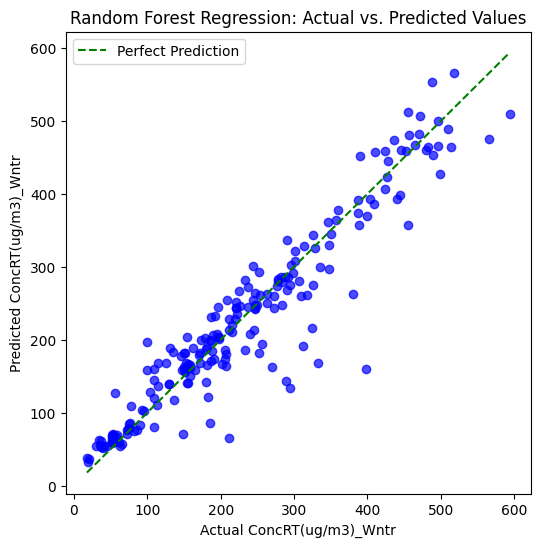

In [53]:
# Plot the predicted vs actual values of test data points
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, color='blue', alpha=0.7)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], linestyle='--', color='green', label='Perfect Prediction')
plt.title("Random Forest Regression: Actual vs. Predicted Values")
plt.xlabel("Actual ConcRT(ug/m3)_Wntr")
plt.ylabel("Predicted ConcRT(ug/m3)_Wntr")
plt.legend()
plt.grid(False)
plt.show()


Extreme Gradient Boost Regressor


In [54]:

from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import xgboost as xgb

In [55]:

# Define your target variable and independent variables
target_column = 'ConcRT(ug/m3)_Atmn'
independent_columns = ['PM₂.₅-AVG_LCS', 'Temperature_LCS', 'Humidity_LCS']


In [56]:
# Split the data into training and testing sets
X = Autumn_df[independent_columns]
y = Autumn_df[target_column]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)



In [57]:
# Initialize the XGBRegressor model
xgb_regressor = xgb.XGBRegressor()


In [58]:
# Define the hyperparameter distributions for randomized search
param_distributions = {
    'n_estimators': list(range(50, 501, 50)),         # Range from 50 to 500 with step size of 50
    'learning_rate': [0.01, 0.05, 0.1, 0.2, 0.3],     # Various learning rates
    'max_depth': list(range(3, 16, 1)),               # Range from 3 to 15 with step size of 1
    'subsample': [i/10.0 for i in range(6, 11)],      # Range from 0.6 to 1.0 with step size of 0.1
    'colsample_bytree': [i/10.0 for i in range(6, 11)]# Range from 0.6 to 1.0 with step size of 0.1
}

In [59]:
# Initialize RandomizedSearchCV
random_search = RandomizedSearchCV(estimator=xgb_regressor, param_distributions=param_distributions,
                                   n_iter=50, scoring='neg_mean_squared_error', cv=5, random_state=42, n_jobs=-1)

# Fit RandomizedSearchCV to the training data
random_search.fit(X_train, y_train)

RandomizedSearchCV(cv=5,
                   estimator=XGBRegressor(base_score=None, booster=None,
                                          callbacks=None,
                                          colsample_bylevel=None,
                                          colsample_bynode=None,
                                          colsample_bytree=None, device=None,
                                          early_stopping_rounds=None,
                                          enable_categorical=True,
                                          eval_metric=None, feature_types=None,
                                          feature_weights=None, gamma=None,
                                          grow_policy=None,
                                          importance_type=None,
                                          interaction_constraints...
                                          n_estimators=None, n_jobs=None,
                                          num_parallel_tree=None, ...),
                   n_iter=50, n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.6, 0.7, 0.8, 0.9,
                                                             1.0],
                                        'learning_rate': [0.01, 0.05, 0.1, 0.2,
                                                          0.3],
                                        'max_depth': [3, 4, 5, 6, 7, 8, 9, 10,
                                                      11, 12, 13, 14, 15],
                                        'n_estimators': [50, 100, 150, 200, 250,
                                                         300, 350, 400, 450,
                                                         500],
                                        'subsample': [0.6, 0.7, 0.8, 0.9, 1.0]},
                   random_state=42, scoring='neg_mean_squared_error')

In [60]:
# Get the best hyperparameters from the randomized search
best_params = random_search.best_params_


In [61]:
# Initialize an XGBRegressor with the best hyperparameters
best_xgb_regressor = xgb.XGBRegressor(**best_params)

# Fit the model to the training data with the best hyperparameters
best_xgb_regressor.fit(X_train, y_train)

# Predict on the test data
y_pred = best_xgb_regressor.predict(X_test)


In [62]:
# Evaluate the model
mse_xgb = mean_squared_error(y_test, y_pred)
rmse_xgb = np.sqrt(mse_xgb)
r2_xgb = r2_score(y_test, y_pred)
mae_xgb = mean_absolute_error(y_test, y_pred)

print("Best Hyperparameters:", best_params)
print("Root Mean Squared Error:", rmse_xgb)
print("R-squared:", r2_xgb)
print("Mean Absolute Error:", mae_xgb)

Best Hyperparameters: {'subsample': 0.6, 'n_estimators': 400, 'max_depth': 3, 'learning_rate': 0.01, 'colsample_bytree': 1.0}
Root Mean Squared Error: 44.561900598507535
R-squared: 0.8886037132721706
Mean Absolute Error: 30.822661342347065


In [63]:
# Get the training score of the model
train_score = best_xgb_regressor.score(X_train, y_train)
print("Training Score:", train_score)

Training Score: 0.9236484434265877


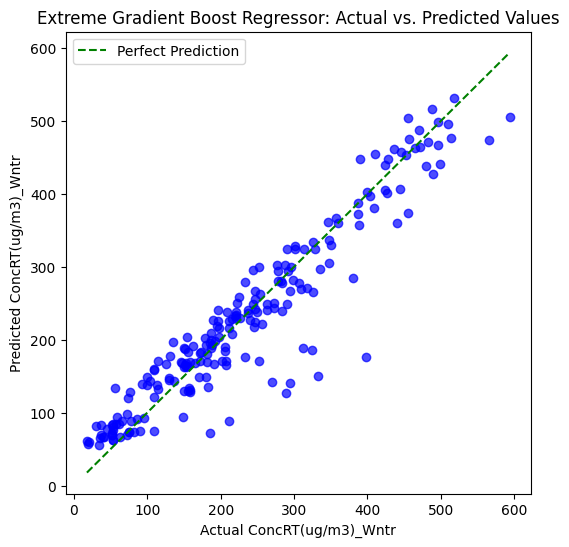

In [64]:
# Plot the predicted vs actual values of test data points
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, color='blue', alpha=0.7)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], linestyle='--', color='green', label='Perfect Prediction')
plt.title("Extreme Gradient Boost Regressor: Actual vs. Predicted Values")
plt.xlabel("Actual ConcRT(ug/m3)_Wntr")
plt.ylabel("Predicted ConcRT(ug/m3)_Wntr")
plt.legend()
plt.grid(False)
plt.show()


 Support Vector Regressor

In [65]:
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error


In [66]:
# Define your target variable and independent variables
target_column = 'ConcRT(ug/m3)_Atmn'
independent_columns = ['PM₂.₅-AVG_LCS', 'Temperature_LCS', 'Humidity_LCS']


In [67]:
# Split the data into training and testing sets
X = Autumn_df[independent_columns]
y = Autumn_df[target_column]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


In [68]:
# Initialize the Support Vector Regressor model
svr_regressor = SVR()


In [69]:
# Define the hyperparameter distributions for randomized search
param_distributions = {
    'C': [0.1,1,10,100],              # Wide range for regularization parameter
    'epsilon': [0.01,0.1,1],      # Various epsilon values for different noise levels
    'gamma': [0.01, 0.1,1],  # Different gamma values for the RBF kernel
    'kernel': ['rbf', 'linear']  # Commonly used kernels
}


In [70]:
# Initialize RandomizedSearchCV
random_search = RandomizedSearchCV(estimator=svr_regressor, param_distributions=param_distributions,
                                   n_iter=50, scoring='neg_mean_squared_error', cv=5, random_state=42, n_jobs=-1)

# Fit RandomizedSearchCV to the training data
random_search.fit(X_train, y_train)

RandomizedSearchCV(cv=5, estimator=SVR(), n_iter=50, n_jobs=-1,
                   param_distributions={'C': [0.1, 1, 10, 100],
                                        'epsilon': [0.01, 0.1, 1],
                                        'gamma': [0.01, 0.1, 1],
                                        'kernel': ['rbf', 'linear']},
                   random_state=42, scoring='neg_mean_squared_error')

In [71]:
# Get the best hyperparameters from the randomized search
best_params = random_search.best_params_

# Initialize an SVR with the best hyperparameters
best_svr_regressor = SVR(**best_params)

# Fit the model to the training data with the best hyperparameters
best_svr_regressor.fit(X_train, y_train)

SVR(C=100, epsilon=0.01, gamma=1, kernel='linear')

In [72]:
# Predict on test data
y_pred = best_svr_regressor.predict(X_test)

In [73]:
# Evaluate the model
mse_svr = mean_squared_error(y_test, y_pred)
rmse_svr = np.sqrt(mse_svr)
r2_svr = r2_score(y_test, y_pred)
mae_svr = mean_absolute_error(y_test, y_pred)

print("Best Hyperparameters:", best_params)
print("Root Mean Squared Error:", rmse_svr)
print("R-squared:", r2_svr)
print("Mean Absolute Error:", mae_svr)

Best Hyperparameters: {'kernel': 'linear', 'gamma': 1, 'epsilon': 0.01, 'C': 100}
Root Mean Squared Error: 55.71279041569214
R-squared: 0.8258782091767043
Mean Absolute Error: 36.77352638999284


In [74]:
# training score of the model
train_score = best_svr_regressor.score(X_train, y_train)
print("Training Score:", train_score)


Training Score: 0.8613563119379966


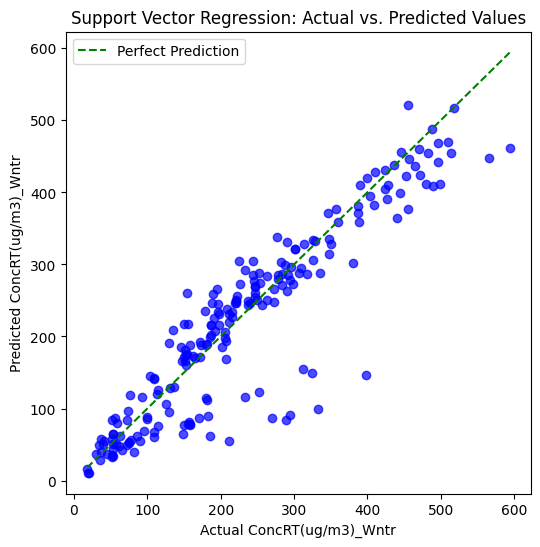

In [75]:
# Plot the predicted vs actual values of test data points
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, color='blue', alpha=0.7)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], linestyle='--', color='green', label='Perfect Prediction')
plt.title("Support Vector Regression: Actual vs. Predicted Values")
plt.xlabel("Actual ConcRT(ug/m3)_Wntr")
plt.ylabel("Predicted ConcRT(ug/m3)_Wntr")
plt.legend()
plt.grid(False)
plt.show()

plot the graph for predicting best model basis on RMSE ,R2 , MAE


In [76]:
import matplotlib.pyplot as plt
import numpy as np

In [77]:
# evaluated Data of each model
models = ['Multiple Linear Regression', 'Random Forest', 'Support Vector Regression', 'Extreme Gradient Boosting']
rmse = [54.209154077963014, 43.935101957266696, 55.71279041569214, 44.945897340596844]
r_squared = [0.835150147161354, 0.8917154289697843,0.8258782091767043,0.8866756036774284 ]
mae = [37.970344779797784,28.863455343023936, 36.77352638999284,30.938663763748973 ]

In [78]:
x = np.arange(len(models))  # the label locations
width = 0.2  # the width of the bars

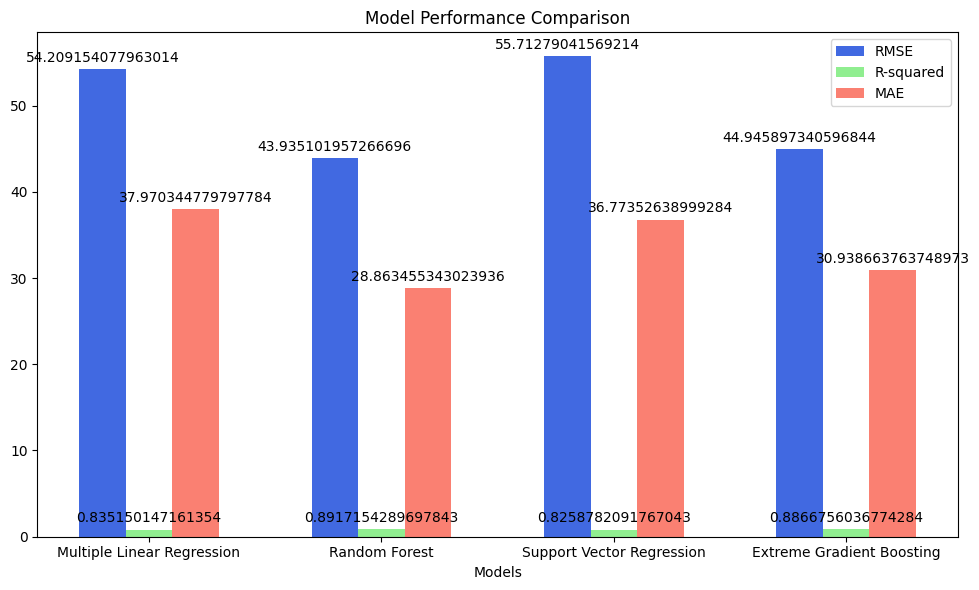

In [79]:
fig, ax = plt.subplots(figsize=(10, 6))

# Creating bars
bars1 = ax.bar(x - width, rmse, width, label='RMSE', color='royalblue')
bars2 = ax.bar(x, r_squared, width, label='R-squared', color='lightgreen')
bars3 = ax.bar(x + width, mae, width, label='MAE', color='salmon')


ax.set_xlabel('Models')
ax.set_title('Model Performance Comparison')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()

# Adding value labels on bars
def add_value_labels(bars):
    for bar in bars:
        height = bar.get_height()
        ax.annotate('{}'.format(height),
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')

add_value_labels(bars1)
add_value_labels(bars2)
add_value_labels(bars3)

plt.tight_layout()
plt.show()

You can see that the Random Forest is the best model for the project
